# Explore hue sensor data: all conditions in a session

Loads every `flash_*.txt` condition file from one session directory and produces, for each condition separately, the same raw-channel and derived-value plots used in `explore_flash_RGY.ipynb`.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

from src.hue.io import load_condition_set
from src.hue.analysis import compute_trial_summary
from src.hue.plotting import plot_raw_channels, plot_trial_summary

## 1. Load all conditions in the session

In [2]:
session_dir = repo_root / "data" / "hue" / "raw" / "data_17JUN26"
sessions = load_condition_set(session_dir)
sorted(sessions)

['G', 'GY', 'R', 'RG', 'RGY', 'RY']

## 2. Per-condition raw channel and derived value plots

Each condition gets its own pair of figures: raw `hue_r`/`hue_g`/`hue_b` vs sample number, and derived per-trCnt mean/delta/distance values.

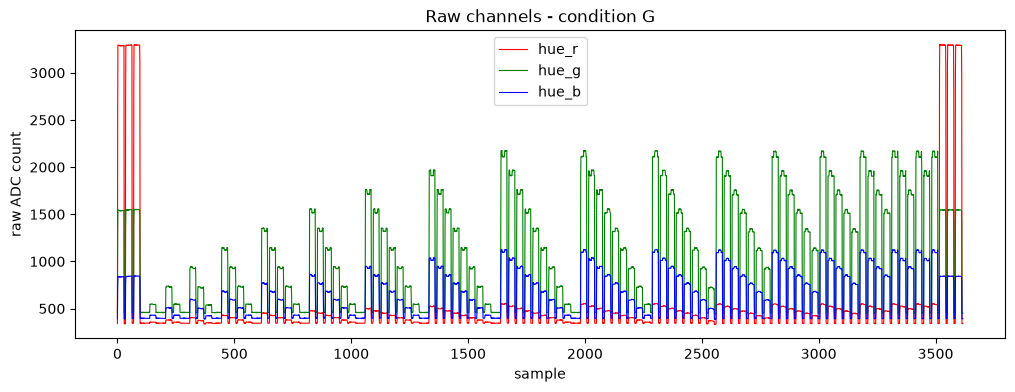

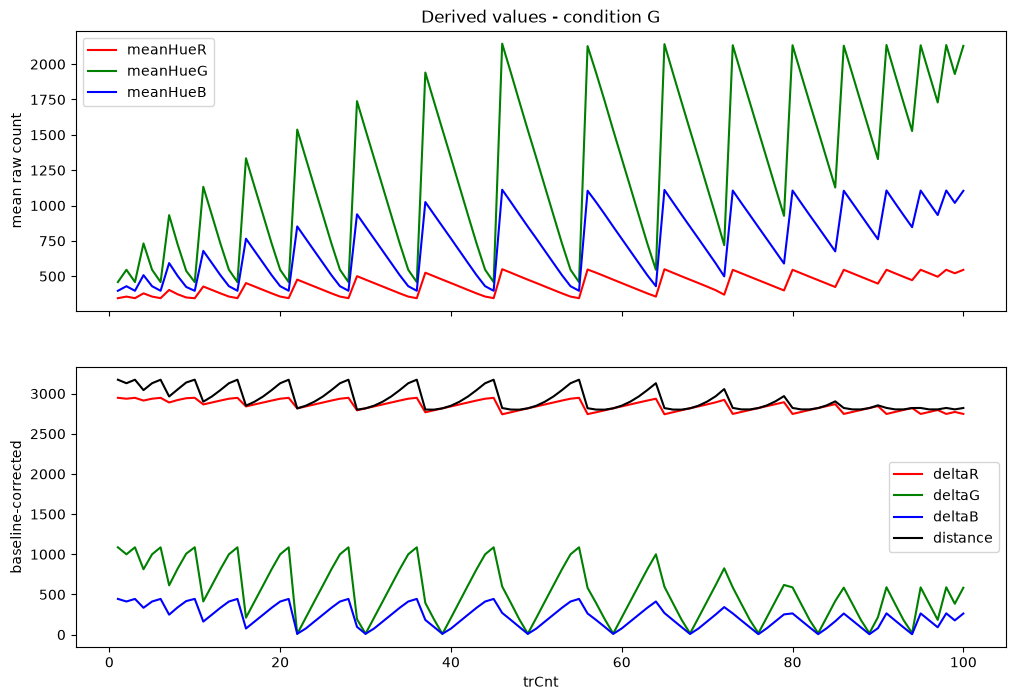

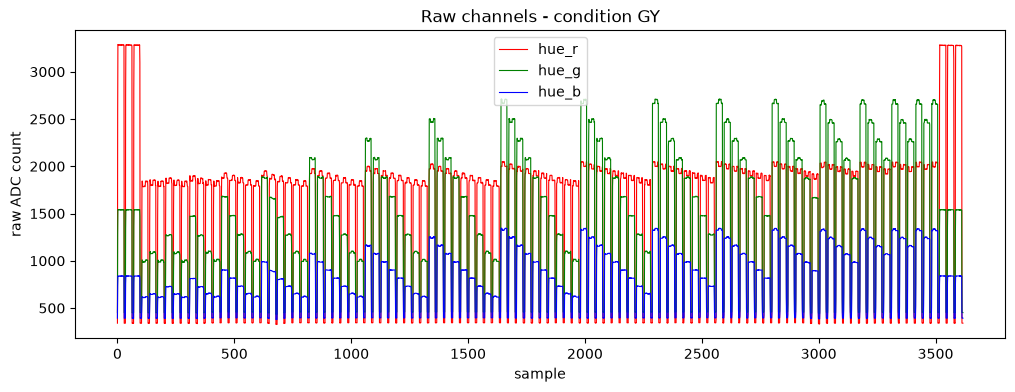

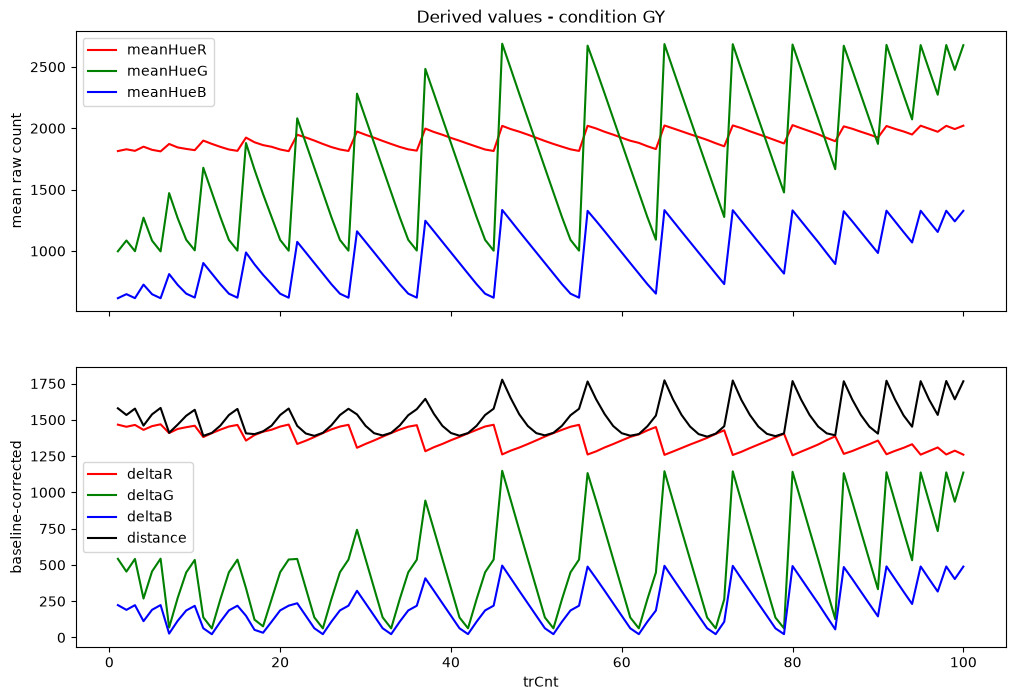

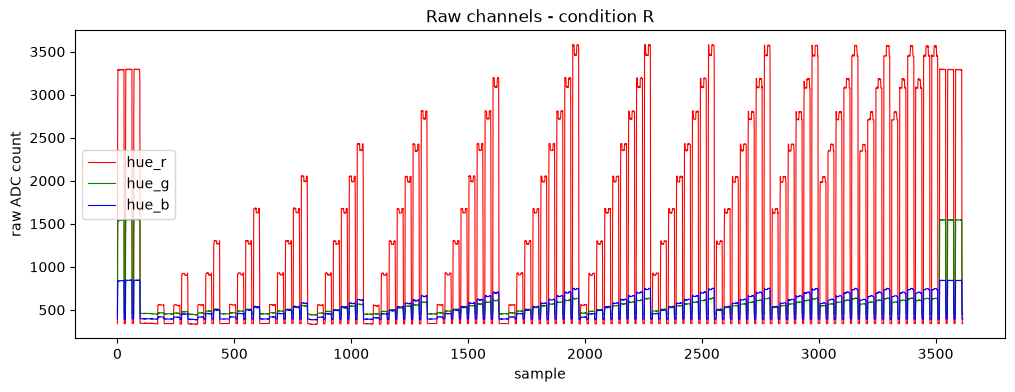

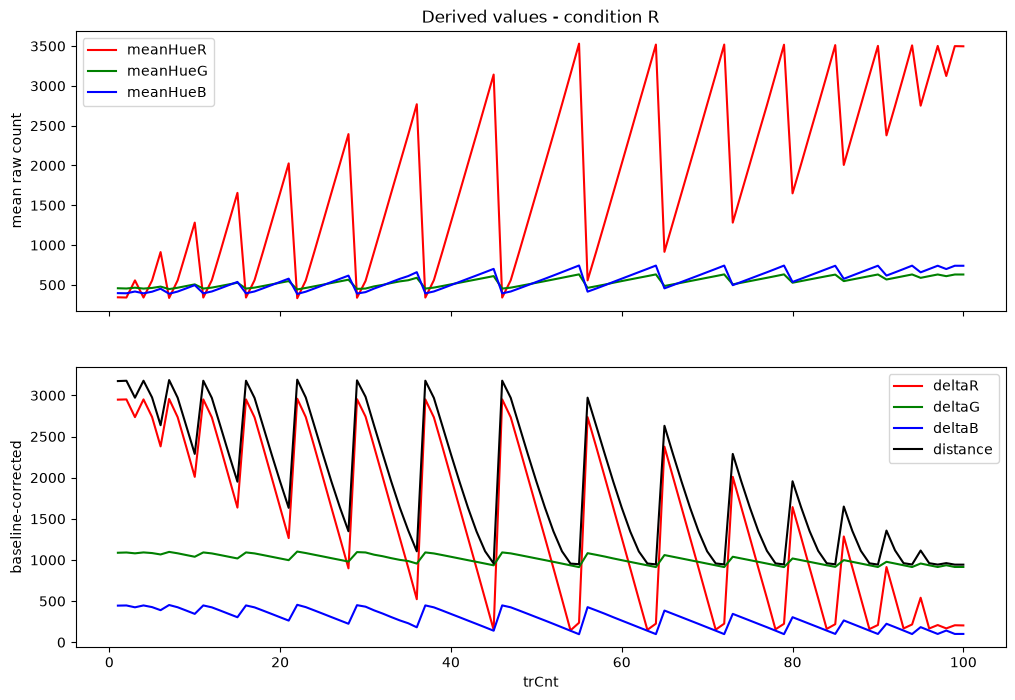

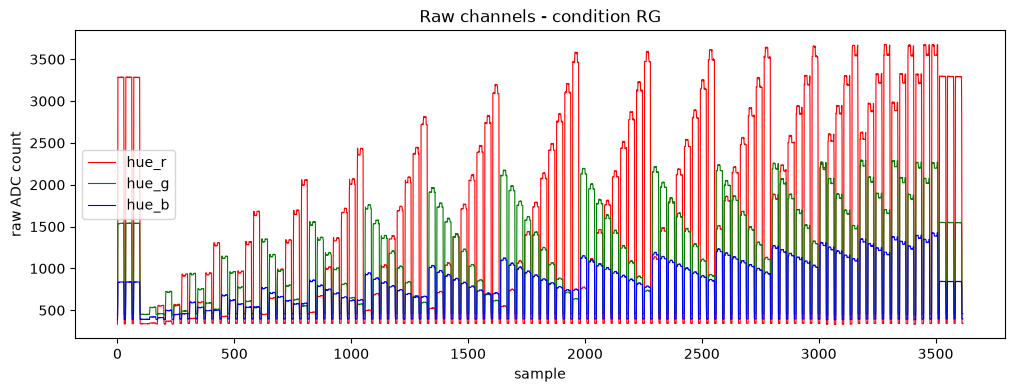

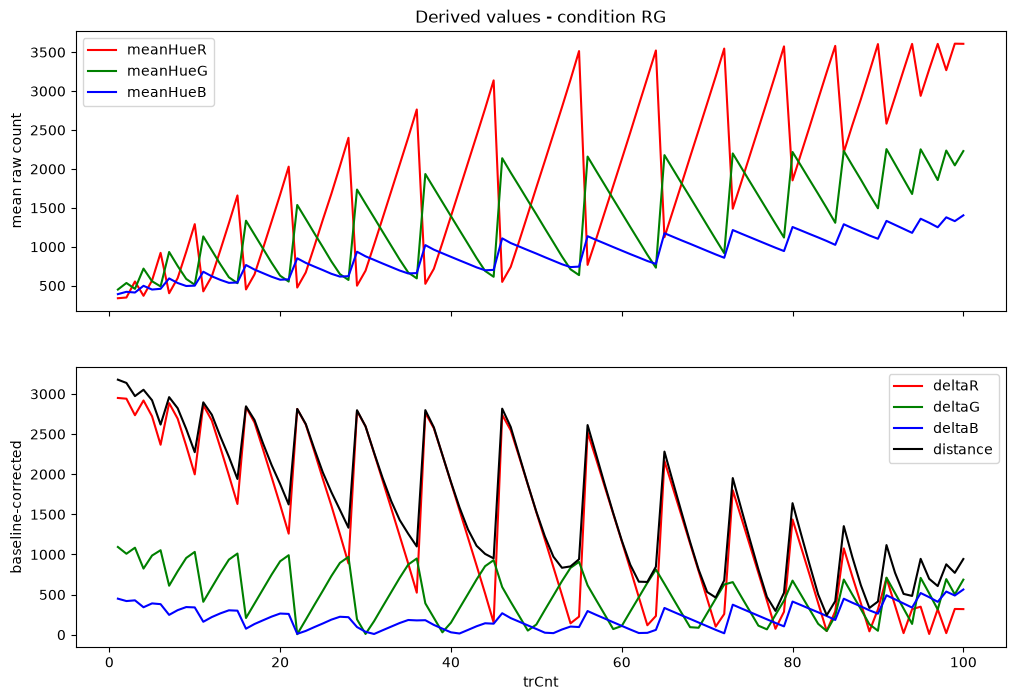

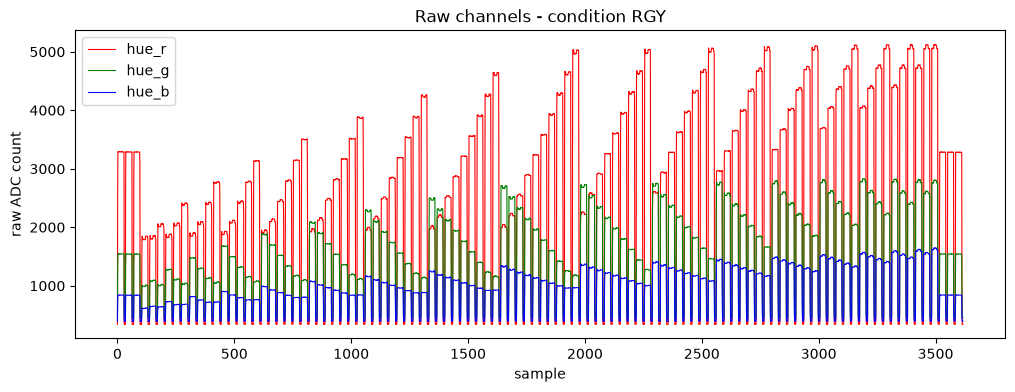

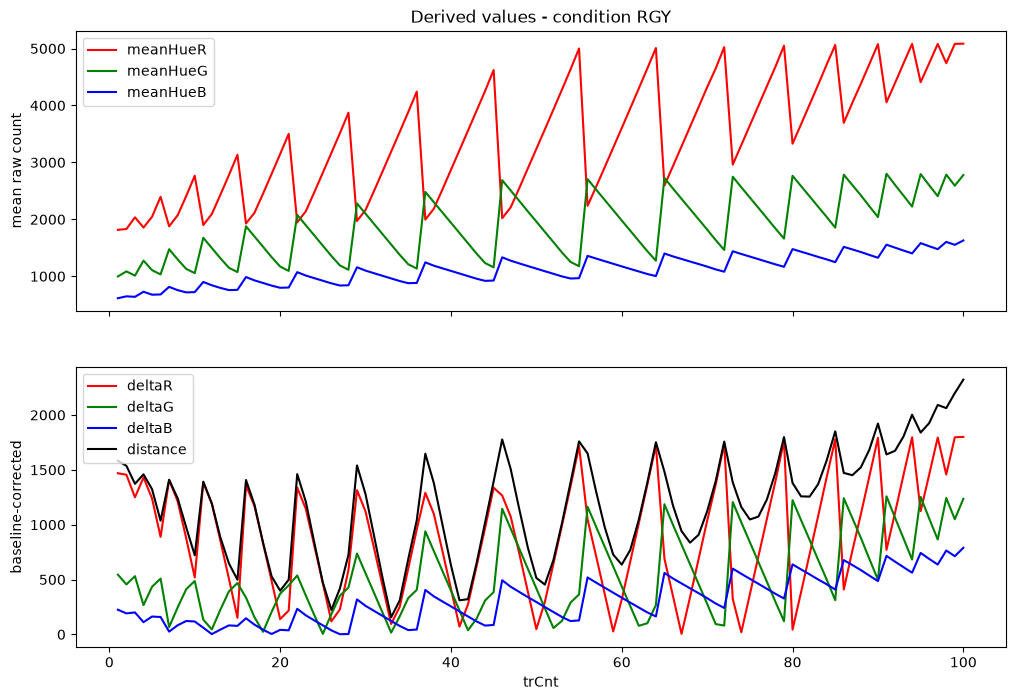

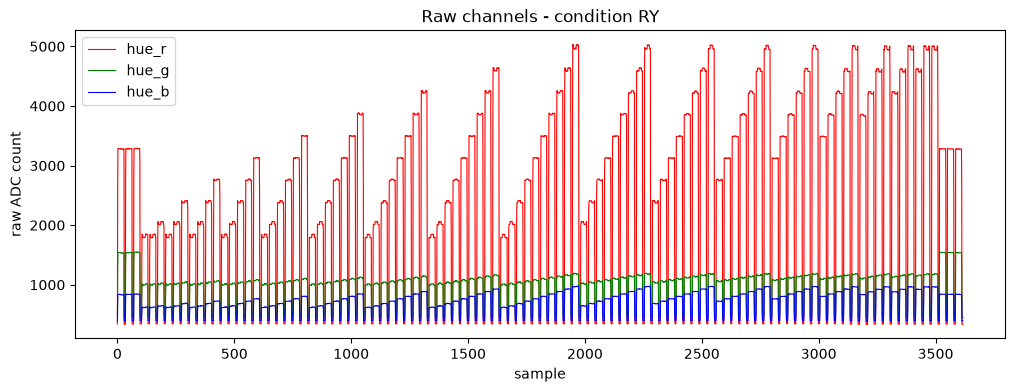

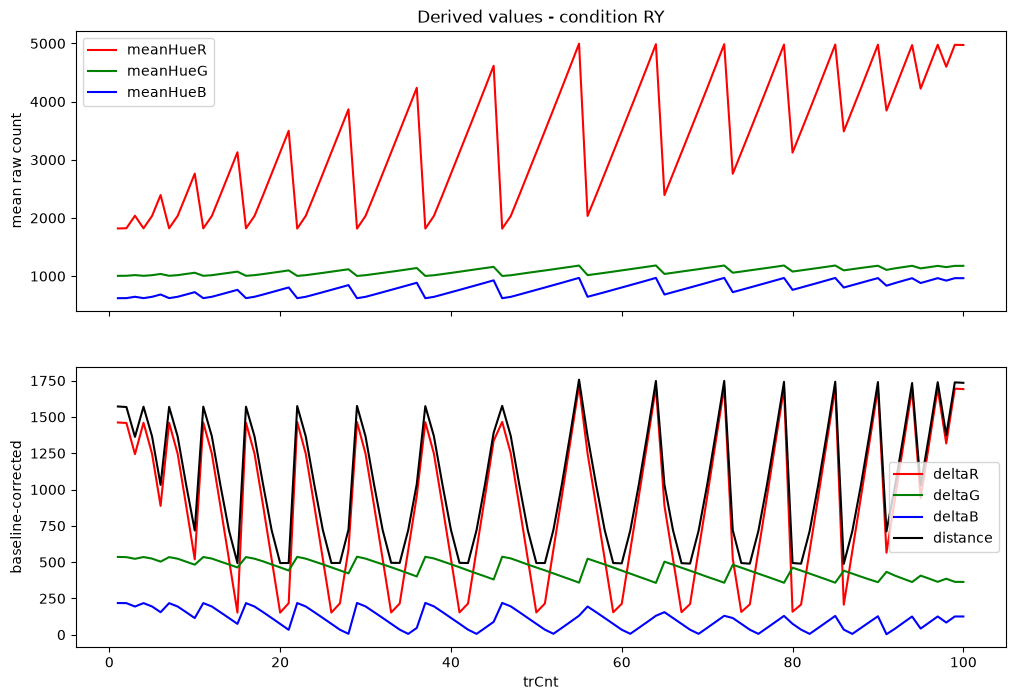

In [3]:
for condition, df in sorted(sessions.items()):
    ax = plot_raw_channels(df)
    ax.set_title(f"Raw channels - condition {condition}")
    plt.show()

    summary = compute_trial_summary(df)
    axes = plot_trial_summary(summary)
    axes[0].set_title(f"Derived values - condition {condition}")
    plt.show()